# Assignment 2

**Credits**: Federico Ruggeri, Eleonora Mancini, Paolo Torroni

**Keywords**: Sexism Detection, Multi-class Classification, LLMs, Prompting

# Setup and Dependencies

In [1]:
!pip -q install -U transformers accelerate bitsandbytes huggingface_hub

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 59.1/59.1 MB 13.4 MB/s eta 0:00:00


In [1]:
from google.colab import userdata
import os
from huggingface_hub import login

In [51]:
import torch
import gc

In [3]:
def get_device():
    if torch.backends.mps.is_available():
        print("Using MPS (Apple Silicon GPU)")
        return torch.device("mps")
    elif torch.cuda.is_available():
        print("Using CUDA")
        return torch.device("cuda")
    else:
        print("Using CPU")
        return torch.device("cpu")

device = get_device()
print(f"PyTorch version: {torch.__version__}")
print(f"Device: {device}")


def empty_cache():
    if torch.cuda.is_available():
        torch.cuda.empty_cache()
    elif torch.backends.mps.is_available():
        torch.mps.empty_cache()
    gc.collect()

Using CUDA
PyTorch version: 2.9.0+cu126
Device: cuda


In [4]:
import pandas as pd
import time

In [5]:
from transformers import AutoTokenizer, AutoModelForCausalLM, BitsAndBytesConfig

In [6]:
import re

In [7]:
import numpy as np
from sklearn.metrics import f1_score, accuracy_score

In [8]:
import random

In [9]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix
from collections import Counter
import torch
import numpy as np
import pandas as pd
from sklearn.metrics import classification_report, confusion_matrix

# Data Loading and EDA

In [10]:
# os.environ["HF_TOKEN"] = userdata.get("HF_TOKEN")
# login(token=os.environ["HF_TOKEN"])

token = userdata.get("HF_TOKEN")
login(token)

In [11]:
test_df = pd.read_csv('data/a2_test.csv')
test_df.head()

,rewire_id,text,label_category
0,sexism2022_english-11647,She may be worth what someone paid for her in ...,derogation
1,sexism2022_english-15883,The men who white knight for women eventually ...,prejudiced
2,sexism2022_english-12494,Two thoughts to keep in mind about women and A...,derogation
3,sexism2022_english-26,"Wimmin. No matter how good they have it, they'...",prejudiced
4,sexism2022_english-7475,"So just a few months ago, while Republican wom...",prejudiced


In [12]:
print(test_df.shape)

(300, 3)


In [13]:
print(test_df['label_category'].value_counts())
print(test_df['label_category'].unique())

label_category
derogation    60
prejudiced    60
animosity     60
not-sexist    60
threats       60
Name: count, dtype: int64
['derogation' 'prejudiced' 'animosity' 'not-sexist' 'threats']


In [14]:
label_to_id = {
    "not-sexist": 0,
    "threats": 1,
    "derogation": 2,
    "animosity": 3,
    "prejudiced": 4,
}

In [15]:
test_texts = test_df["text"].tolist()
test_labels = test_df["label_category"].map(label_to_id).tolist()

# Model setup

In [16]:
MODEL_CONFIGS = [
    {
        "name": "TinyLlama/TinyLlama-1.1B-Chat-v1.0",
        "nickname": "TinyLlama"
    },
    {
        "name": "Qwen/Qwen3-1.7B",
        "nickname": "Qwen3"
    },
]

In [17]:
def load_model(model_name: str):
    """
    Loads a Language Model with device-specific optimization:
    - CUDA: 4-bit quantization via bitsandbytes
    - MPS: float16 weights (bnb quantization not supported reliably)
    - CPU: float32 weights
    Returns: (model, tokenizer)
    """
    print(f"Loading {model_name}")

    bnb_config = None
    device_map = None

    if device.type == "cuda":
        compute_dtype = torch.bfloat16 if torch.cuda.is_bf16_supported() else torch.float16
        bnb_config = BitsAndBytesConfig(
            load_in_4bit=True,
            bnb_4bit_use_double_quant=True,
            bnb_4bit_quant_type="nf4",
            bnb_4bit_compute_dtype=compute_dtype,
        )
        torch_dtype = None
        device_map = "auto"

    elif device.type == "mps":
        torch_dtype = torch.float16

    else:  # CPU
        torch_dtype = torch.float32

    model = AutoModelForCausalLM.from_pretrained(
        model_name,
        quantization_config=bnb_config,
        torch_dtype=torch_dtype,
        device_map=device_map,
        trust_remote_code=False,
        low_cpu_mem_usage=True,
    )

    tokenizer = AutoTokenizer.from_pretrained(model_name, trust_remote_code=False)

    # Padding setup (important for batching + left padding for decoder-only models)
    if tokenizer.pad_token is None:
        tokenizer.pad_token = tokenizer.eos_token
    tokenizer.padding_side = "left"

    model.config.pad_token_id = tokenizer.pad_token_id

    # On non-CUDA, move model explicitly
    if device.type != "cuda":
        model.to(device)

    model.eval()
    print(f"✓ Loaded on {device}")
    return model, tokenizer

In [18]:
models = {}

for cfg in MODEL_CONFIGS:
    model, tokenizer = load_model(cfg["name"])
    models[cfg["nickname"]] = {
        "name": cfg["name"],
        "model": model,
        "tokenizer": tokenizer
    }

Loading TinyLlama/TinyLlama-1.1B-Chat-v1.0


config.json:   0%|          | 0.00/608 [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/2.20G [00:00<?, ?B/s]

generation_config.json:   0%|          | 0.00/124 [00:00<?, ?B/s]

tokenizer_config.json: 0.00B [00:00, ?B/s]

...

tokenizer_config.json: 0.00B [00:00, ?B/s]

vocab.json: 0.00B [00:00, ?B/s]

merges.txt: 0.00B [00:00, ?B/s]

tokenizer.json:   0%|          | 0.00/11.4M [00:00<?, ?B/s]

✓ Loaded on cuda


In [19]:
print("Loaded models:", list(models.keys()))

Loaded models: ['TinyLlama', 'Qwen3']


# Prompt setup

In [20]:
zero_shot_prompt = [
    {
        'role': 'system',
        'content': 'You are an annotator for sexism detection.'
    },
    {
        'role': 'user',
        'content': """Your task is to classify input text as not-sexist
         or sexist. If sexist, classify input text according to one
         of the following four categories: threats, derogation,
         animosity, prejudiced discussion.

         Below you find sexist categories definitions:
         Threats: the text expresses intent or desire to harm a woman.
         Derogation: the text describes a woman in a derogative manner.
         Animosity: the text contains slurs or insults towards a woman.
         Prejudiced discussion: the text expresses supports for
         mistreatment of women as individuals.

         Respond only by writing one of the following categories:
         not-sexist, threats, derogation, animosity, prejudiced.

        TEXT: {text}

        ANSWER:
        """
    }
]

In [21]:
few_shot_prompt = [
    {
        'role': 'system',
        'content': 'You are an annotator for sexism detection.'
    },
    {
        'role': 'user',
        'content': """Your task is to classify input text as not-sexist
         or sexist. If sexist, classify input text according to one
         of the following four categories: threats, derogation,
         animosity, prejudiced discussion.

         Below you find sexist categories definitions:
         Threats: the text expresses intent or desire to harm a woman.
         Derogation: the text describes a woman in a derogative manner.
         Animosity: the text contains slurs or insults towards a woman.
         Prejudiced discussion: the text expresses supports for
         mistreatment of women as individuals.

         Respond only by writing one of the following categories:
         not-sexist, threats, derogation, animosity, prejudiced.

        EXAMPLES: {examples}

        TEXT: {text}

        ANSWER:
        """
    }
]

In [22]:
def prepare_prompts(texts, prompt_template, tokenizer, examples=None):
    """
    Format input text samples into instruction prompts.

    Inputs:
      texts: list[str] input texts to classify via prompting
      prompt_template: the prompt template provided in this assignment (list of role/content dicts)
      tokenizer: the transformers tokenizer associated with the chosen model
      examples: optional. Either:
        - None (zero-shot)
        - str (same examples prepended for every text)
        - list[str] (one examples string per text)

    Output:
      list[str] prompts ready to pass to the model
    """
    formatted_prompts = []

    # Helper: get the examples string for each index
    def get_examples(i):
        if examples is None:
            return ""
        if isinstance(examples, (list, tuple)):
            return examples[i]
        return examples  # single string for all texts

    has_chat_template = (
        hasattr(tokenizer, "apply_chat_template")
        and getattr(tokenizer, "chat_template", None) is not None
    )

    for i, text in enumerate(texts):
        ex = get_examples(i)

        # Build a fresh prompt list (no deep copy needed)
        current_prompt = []
        for msg in prompt_template:
            if msg["role"] == "user":
                content = msg["content"].format(text=text.strip(), examples=ex)
                current_prompt.append({"role": "user", "content": content})
            else:
                current_prompt.append({"role": msg["role"], "content": msg["content"]})

        # Preferred: model-specific chat formatting
        if has_chat_template:
            try:
                formatted = tokenizer.apply_chat_template(
                    current_prompt,
                    tokenize=False,
                    add_generation_prompt=True,
                    enable_thinking=False,
                )
            except TypeError:
                formatted = tokenizer.apply_chat_template(
                    current_prompt,
                    tokenize=False,
                    add_generation_prompt=True
                )

        else:
            # Fallback: plain text formatting (still valid)
            # Keep content identical; just concatenate roles for readability
            parts = []
            for msg in current_prompt:
                parts.append(f"{msg['role'].upper()}:\n{msg['content'].strip()}\n")
            formatted = "\n".join(parts)

        formatted_prompts.append(formatted)

    return formatted_prompts

In [23]:
test_texts = test_df["text"].tolist()

prompts_by_model = {}
for nickname, bundle in models.items():
    tok = bundle["tokenizer"]
    prompts_by_model[nickname] = prepare_prompts(test_texts, zero_shot_prompt, tok)

for nickname in prompts_by_model:
    print("\n==============================")
    print("MODEL:", nickname)
    print(prompts_by_model[nickname][0][:800])


MODEL: TinyLlama
<|system|>
You are an annotator for sexism detection.</s>
<|user|>
Your task is to classify input text as not-sexist
         or sexist. If sexist, classify input text according to one
         of the following four categories: threats, derogation,
         animosity, prejudiced discussion.

         Below you find sexist categories definitions:
         Threats: the text expresses intent or desire to harm a woman.
         Derogation: the text describes a woman in a derogative manner.
         Animosity: the text contains slurs or insults towards a woman.
         Prejudiced discussion: the text expresses supports for
         mistreatment of women as individuals.

         Respond only by writing one of the following categories:
         not-sexist, threats, derogation, animosity, prejud

MODEL: Qwen3
<|im_start|>system
You are an annotator for sexism detection.<|im_end|>
<|im_start|>user
Your task is to classify input text as not-sexist
         or sexist. If sexis

# Inference

In [24]:
def generate_responses(model, tokenizer, prompt_examples, batch_size=4, max_new_tokens=20, max_length=2048):
    """
    Inference loop: prompt the LLM with each pre-processed prompt and generate responses.

    Inputs:
      model: LLM model instance
      tokenizer: tokenizer associated with this model
      prompt_examples: list[str] prompts (already pre-processed)
    Outputs:
      list[str] generated responses
    """
    all_responses = []

    for i in range(0, len(prompt_examples), batch_size):
        batch_prompts = prompt_examples[i:i + batch_size]

        enc = tokenizer(
            batch_prompts,
            truncation=True,
            max_length=max_length,
            return_tensors="pt",
            padding=True,
        )

        # Move inputs to the same device you’re using
        enc = {k: v.to(device) for k, v in enc.items()}

        with torch.inference_mode():
            generated_ids = model.generate(
                **enc,
                max_new_tokens=max_new_tokens,
                do_sample=False,
                pad_token_id=tokenizer.pad_token_id,
                eos_token_id=tokenizer.eos_token_id,
            )

        # Remove the prompt tokens from the output to keep only the answer
        input_len = enc["input_ids"].shape[1]
        generated_only = generated_ids[:, input_len:]

        responses = tokenizer.batch_decode(generated_only, skip_special_tokens=True)
        all_responses.extend(responses)

    return all_responses


In [25]:
def process_response(response: str) -> int:
    """
    Parse model output text into a 5-class label id using label_to_id.
    Returns -1 if it cannot be parsed.
    """
    if response is None:
        return -1

    r = response.strip().lower()
    r = r.replace("_", "-")
    r = r.replace("not sexist", "not-sexist")
    r = r.replace("prejudiced discussion", "prejudiced")

    # Exact match
    if r in label_to_id:
        return label_to_id[r]

    # Normalize spaces -> hyphens
    r2 = r.replace(" ", "-")
    if r2 in label_to_id:
        return label_to_id[r2]

    # Regex search for labels (robust to hyphens/spaces)
    for label, label_id in label_to_id.items():
        pattern = label.replace("-", r"[-\s]?")
        if re.search(rf"\b{pattern}\b", r, flags=re.IGNORECASE):
            return label_id

    # Last fallback (partial)
    if "not-sexist" in r or "not sexist" in r:
        return 0
    if "threat" in r:
        return 1
    if "derogat" in r:
        return 2
    if "animosit" in r:
        return 3
    if "prejudic" in r:
        return 4

    return -1


In [26]:
def zero_shot_inference(model_name: str, model, tokenizer):
    """
    Run zero-shot inference for one model/tokenizer pair.
    """
    print("\n" + "="*60)
    print(f"Running ZERO-SHOT inference with {model_name}")
    print("="*60)

    start_time = time.time()

    prompts = prepare_prompts(test_texts, zero_shot_prompt, tokenizer)
    responses = generate_responses(model, tokenizer, prompts)
    predictions = [process_response(r) for r in responses]

    elapsed = time.time() - start_time
    print(f"✓ {model_name} completed in {elapsed:.2f}s (avg {elapsed/len(test_texts):.3f}s/sample)")

    return {
        "responses": responses,
        "predictions": predictions,
        "ground_truth": test_labels,
        "inference_time": elapsed
    }

In [27]:
zero_shot_results = {}

for nickname, bundle in models.items():
    zero_shot_results[nickname] = zero_shot_inference(
        model_name=nickname,
        model=bundle["model"],
        tokenizer=bundle["tokenizer"]
    )


Running ZERO-SHOT inference with TinyLlama


The following generation flags are not valid and may be ignored: ['temperature', 'top_p', 'top_k']. Set `TRANSFORMERS_VERBOSITY=info` for more details.


✓ TinyLlama completed in 277.76s (avg 0.926s/sample)

Running ZERO-SHOT inference with Qwen3
✓ Qwen3 completed in 130.41s (avg 0.435s/sample)


In [28]:
for nickname, bundle in models.items():
    m = bundle["model"]
    t = bundle["tokenizer"]
    print(nickname, "vocab:", len(t), "| model type:", type(m).__name__)

TinyLlama vocab: 32000 | model type: LlamaForCausalLM
Qwen3 vocab: 151669 | model type: Qwen3ForCausalLM


#Metrics

In [29]:
def compute_metrics(y_pred, y_true):
    """
    Compute accuracy, macro F1-score, and fail-ratio.

    - fail-ratio: fraction of invalid predictions (y_pred == -1)
    - for accuracy/F1: invalid predictions are mapped to 0 (not-sexist) as per assignment rule
    """
    y_pred = np.array(y_pred, dtype=int)
    y_true = np.array(y_true, dtype=int)

    # Fail ratio = how many invalid outputs
    fail_ratio = np.mean(y_pred == -1)

    # Map invalid outputs to 0 ("not-sexist") for evaluation (per professor instructions)
    y_pred_eval = y_pred.copy()
    y_pred_eval[y_pred_eval == -1] = 0

    accuracy = accuracy_score(y_true, y_pred_eval)

    macro_f1 = f1_score(
        y_true,
        y_pred_eval,
        average="macro",
        labels=[0, 1, 2, 3, 4],   # ensure we compute over exactly these classes
        zero_division=0
    )

    return {
        "accuracy": float(accuracy),
        "macro_f1": float(macro_f1),
        "fail_ratio": float(fail_ratio),
    }

In [30]:
zero_shot_metrics = {}

for nickname, results in zero_shot_results.items():
    m = compute_metrics(results["predictions"], results["ground_truth"])
    zero_shot_metrics[nickname] = m

    print(f"\n{nickname} Results")
    print(f"Accuracy:   {m['accuracy']:.4f}")
    print(f"Macro F1:   {m['macro_f1']:.4f}")
    print(f"Fail Ratio: {m['fail_ratio']:.4f}")


TinyLlama Results
Accuracy:   0.2300
Macro F1:   0.1318
Fail Ratio: 0.4133

Qwen3 Results
Accuracy:   0.2900
Macro F1:   0.2154
Fail Ratio: 0.0000


# Few-shot Inference

In [31]:
demo_df = pd.read_csv('data/demonstrations.csv')
demo_df.head()

,rewire_id,text,label_sexist,label_category,label_vector,split
0,sexism2022_english-7417,female egg donors are allowed to be uggo as fu...,sexist,derogation,2.1 descriptive attacks,train
1,sexism2022_english-10155,My girlfriend is mentally retarded. Or if you ...,sexist,derogation,2.1 descriptive attacks,test
2,sexism2022_english-15154,Lock her UP!!!!,sexist,threats,1.2 incitement and encouragement of harm,train
3,sexism2022_english-13387,So you want to live in a world where women are...,sexist,animosity,"3.1 casual use of gendered slurs, profanities,...",dev
4,sexism2022_english-2990,"Special episode of Loomy Does Politics, by pop...",sexist,prejudiced,4.2 supporting systemic discrimination against...,train


In [32]:
def build_few_shot_demonstrations(demonstrations, num_per_class=2, seed=25):
    """
    Inputs:
      demonstrations: DataFrame wrapping demonstrations.csv
      num_per_class: number of demonstrations per class

    Outputs:
      list[str] demonstrations to inject into the prompt template
    """
    demo_strings = []

    # sample num_per_class examples per class
    for label, group in demonstrations.groupby("label_category"):
        n = min(num_per_class, len(group))  # safety
        sampled = group.sample(n=n, random_state=seed)

        for _, row in sampled.iterrows():
            demo_strings.append(
                f"TEXT: {str(row['text']).strip()}\nANSWER: {str(row['label_category']).strip()}"
            )

    # reproducible shuffle
    rng = random.Random(seed)
    rng.shuffle(demo_strings)

    return demo_strings

In [33]:
NUM_PER_CLASS = 2

In [34]:
few_shot_demo_list = build_few_shot_demonstrations(demo_df, num_per_class=NUM_PER_CLASS, seed=25)
few_shot_examples = "\n\n".join(few_shot_demo_list)

In [35]:
print("Few-shot examples preview:\n")
print(few_shot_examples[:500])

Few-shot examples preview:

TEXT: [USER] I hope, I don't like this woman, WHOtf does she think she is banning a part of oiur History! she SUCKS!
ANSWER: not-sexist

TEXT: What else would attack a 70-year-old woman with a machete other than a Negro? Okay, a Mexican. Or Muslim. [URL]
ANSWER: not-sexist

TEXT: Yeah I'll echo DrSleeper here; women are typically very gracious or hurt. &#x200B; &#x200B;
ANSWER: animosity

TEXT: Divorce,your dumb bitch of a wife and accuse her of rape and infidelity
ANSWER: threats

TEXT: Regardi


In [36]:
def few_shot_inference(model_name: str, model, tokenizer, few_shot_examples: str):
    print("\n" + "="*60)
    print(f"Running FEW-SHOT inference with {model_name} (num_per_class={NUM_PER_CLASS})")
    print("="*60)

    start_time = time.time()

    prompts = prepare_prompts(
        texts=test_texts,
        prompt_template=few_shot_prompt,
        tokenizer=tokenizer,
        examples=few_shot_examples
    )

    responses = generate_responses(model, tokenizer, prompts)
    predictions = [process_response(r) for r in responses]

    elapsed = time.time() - start_time
    print(f"✓ {model_name} completed in {elapsed:.2f}s (avg {elapsed/len(test_texts):.3f}s/sample)")

    return {
        "responses": responses,
        "predictions": predictions,
        "ground_truth": test_labels,
        "inference_time": elapsed
    }

In [37]:
few_shot_results = {}

for nickname, bundle in models.items():
    few_shot_results[nickname] = few_shot_inference(
        model_name=nickname,
        model=bundle["model"],
        tokenizer=bundle["tokenizer"],
        few_shot_examples=few_shot_examples
    )


Running FEW-SHOT inference with TinyLlama (num_per_class=2)
✓ TinyLlama completed in 410.90s (avg 1.370s/sample)

Running FEW-SHOT inference with Qwen3 (num_per_class=2)
✓ Qwen3 completed in 302.10s (avg 1.007s/sample)


In [38]:
few_shot_metrics = {}

for nickname, results in few_shot_results.items():
    m = compute_metrics(results["predictions"], results["ground_truth"])
    few_shot_metrics[nickname] = m

    print(f"\n{nickname} (few-shot) Results:")
    print(f"Accuracy:   {m['accuracy']:.4f}")
    print(f"Macro F1:   {m['macro_f1']:.4f}")
    print(f"Fail Ratio: {m['fail_ratio']:.4f}")


TinyLlama (few-shot) Results:
Accuracy:   0.2000
Macro F1:   0.0667
Fail Ratio: 0.0000

Qwen3 (few-shot) Results:
Accuracy:   0.2700
Macro F1:   0.1799
Fail Ratio: 0.0000


In [39]:
print("\n" + "="*70)
print("Zero-shot vs Few-shot comparison")
print("="*70)

for nickname in models.keys():
    z = compute_metrics(zero_shot_results[nickname]["predictions"], zero_shot_results[nickname]["ground_truth"])
    f = few_shot_metrics[nickname]
    print(f"\n{nickname}")
    print(f"  Zero-shot  Macro F1: {z['macro_f1']:.4f} | Fail: {z['fail_ratio']:.4f}")
    print(f"  Few-shot   Macro F1: {f['macro_f1']:.4f} | Fail: {f['fail_ratio']:.4f}")


Zero-shot vs Few-shot comparison

TinyLlama
  Zero-shot  Macro F1: 0.1318 | Fail: 0.4133
  Few-shot   Macro F1: 0.0667 | Fail: 0.0000

Qwen3
  Zero-shot  Macro F1: 0.2154 | Fail: 0.0000
  Few-shot   Macro F1: 0.1799 | Fail: 0.0000


In [40]:
# for r in zero_shot_results["Qwen3"]["responses"][:5]:
#     print(repr(r[:300]))

# Error Analysis

In [41]:
id2label = {v: k for k, v in label_to_id.items()}
LABEL_IDS = [0, 1, 2, 3, 4]
LABEL_NAMES = [id2label[i] for i in LABEL_IDS]

In [43]:
def build_performance_table(z_metrics, f_metrics, z_results, f_results):
    rows = []
    for model_name in z_metrics.keys():
        rows.append({
            "Model": model_name,
            "Setting": "zero-shot",
            "Accuracy": z_metrics[model_name]["accuracy"],
            "Macro F1": z_metrics[model_name]["macro_f1"],
            "Fail Ratio": z_metrics[model_name]["fail_ratio"],
            "Inference Time (s)": z_results[model_name]["inference_time"]
        })
        rows.append({
            "Model": model_name,
            "Setting": "few-shot",
            "Accuracy": f_metrics[model_name]["accuracy"],
            "Macro F1": f_metrics[model_name]["macro_f1"],
            "Fail Ratio": f_metrics[model_name]["fail_ratio"],
            "Inference Time (s)": f_results[model_name]["inference_time"]
        })

    df = pd.DataFrame(rows)
    df = df.sort_values(["Model", "Setting"]).reset_index(drop=True)
    return df

results_table = build_performance_table(
    zero_shot_metrics, few_shot_metrics,
    zero_shot_results, few_shot_results
)

results_table

,Model,Setting,Accuracy,Macro F1,Fail Ratio,Inference Time (s)
0,Qwen3,few-shot,0.27,0.179891,0.000000,302.098743
1,Qwen3,zero-shot,0.29,0.215358,0.000000,130.411496
2,TinyLlama,few-shot,0.20,0.066667,0.000000,410.900854
3,TinyLlama,zero-shot,0.23,0.131816,0.413333,277.763122


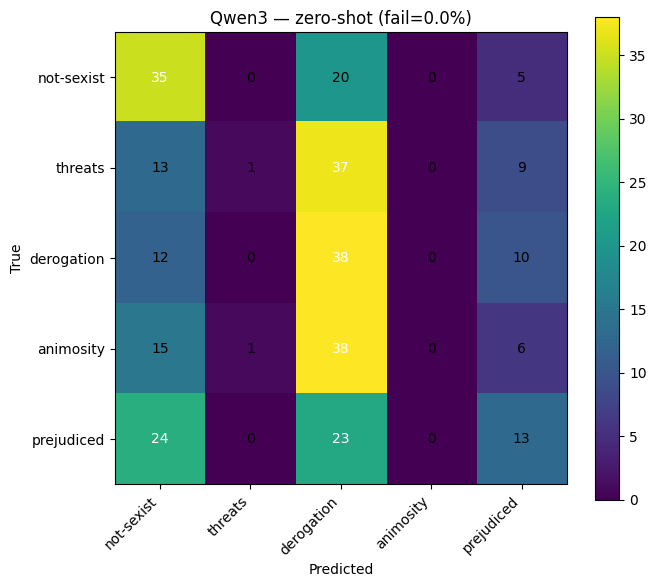

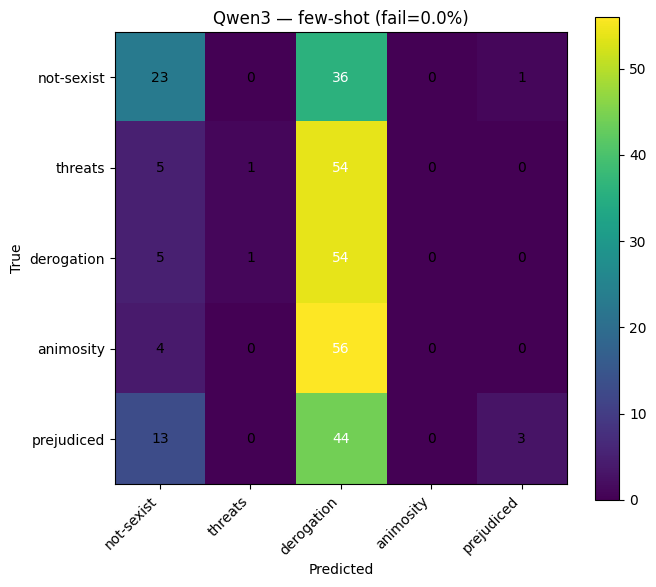

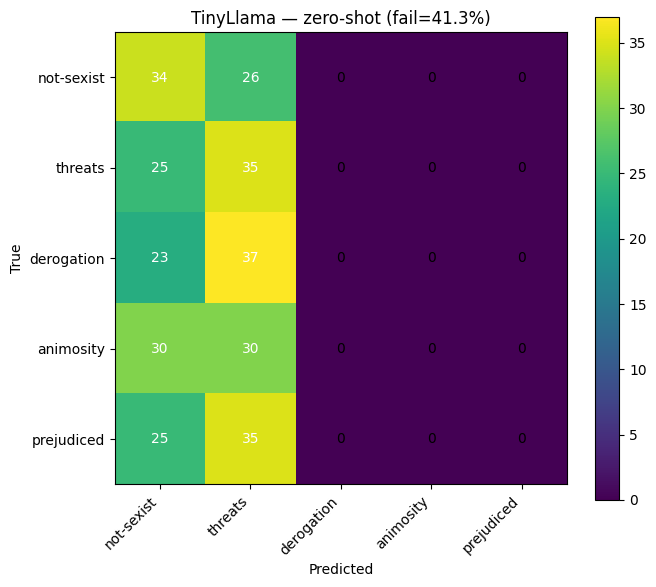

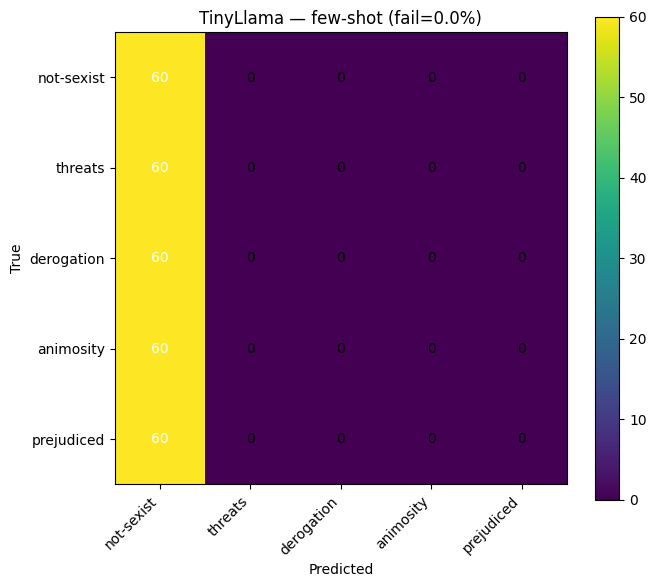

In [44]:
def plot_confusion_matrix(results, title):
    y_true = np.array(results["ground_truth"], dtype=int)
    y_pred = np.array(results["predictions"], dtype=int)

    fail_ratio = np.mean(y_pred == -1)
    y_pred_eval = y_pred.copy()
    y_pred_eval[y_pred_eval == -1] = 0  # invalid -> not-sexist (0) per assignment

    cm = confusion_matrix(y_true, y_pred_eval, labels=LABEL_IDS)

    plt.figure(figsize=(7, 6))
    plt.imshow(cm, interpolation="nearest")
    plt.title(f"{title} (fail={fail_ratio:.1%})")
    plt.colorbar()
    tick_marks = np.arange(len(LABEL_NAMES))
    plt.xticks(tick_marks, LABEL_NAMES, rotation=45, ha="right")
    plt.yticks(tick_marks, LABEL_NAMES)

    # annotate cells
    thresh = cm.max() * 0.6 if cm.max() > 0 else 1
    for i in range(cm.shape[0]):
        for j in range(cm.shape[1]):
            val = cm[i, j]
            plt.text(j, i, str(val),
                     ha="center", va="center",
                     color="white" if val > thresh else "black")

    plt.ylabel("True")
    plt.xlabel("Predicted")
    plt.tight_layout()
    plt.show()

for model_name in results_table["Model"].unique():
    plot_confusion_matrix(zero_shot_results[model_name], f"{model_name} — zero-shot")
    plot_confusion_matrix(few_shot_results[model_name], f"{model_name} — few-shot")

You can literally adapt these bullets:
Compliance / generation quality
TinyLlama zero-shot has high fail-ratio (~41%), meaning it often doesn’t follow the “respond only with label” rule. Few-shot reduces fail-ratio to ~0%, so demonstrations improve instruction-following.
Qwen3 produces valid labels consistently in both modes (fail-ratio 0%), showing stronger instruction adherence.
Performance gap
Qwen3 outperforms TinyLlama in macro-F1 in both settings.
Few-shot does not necessarily improve macro-F1 here: both models drop in macro-F1, suggesting the chosen demonstrations may bias outputs or reduce generalization.
Error patterns
From your sanity check, Qwen3 tends to overpredict derogation, confusing it with animosity and threats; confusion matrices will show which true classes collapse into which predicted class.

In [47]:
def nll_true_label_for_samples(model, tokenizer, prompts, true_label_ids, max_length=2048):
    """
    Compute per-sample NLL of the true label string given the prompt.
    Returns an array of NLL values aligned with prompts.
    """
    # map true ids -> label string
    true_label_strs = [id2label[int(i)] for i in true_label_ids]

    nll = np.zeros(len(prompts), dtype=float)

    # compute NLL label-by-label to avoid per-sample overhead
    for lbl in LABEL_NAMES:
        idx = [i for i, t in enumerate(true_label_strs) if t == lbl]
        if not idx:
            continue

        sub_prompts = [prompts[i] for i in idx]

        # tokenize prompts (batch)
        enc = tokenizer(
            sub_prompts,
            truncation=True,
            max_length=max_length,
            return_tensors="pt",
            padding=True,
        )
        enc = {k: v.to(device) for k, v in enc.items()}

        # tokenize label string
        label_ids = tokenizer(lbl, add_special_tokens=False)["input_ids"]
        label_ids = torch.tensor(label_ids, dtype=torch.long, device=device)

        with torch.inference_mode():
            for b in range(enc["input_ids"].shape[0]):
                input_ids = enc["input_ids"][b]
                attn = enc["attention_mask"][b]
                prompt_len = int(attn.sum().item())
                prompt_ids = input_ids[:prompt_len]

                full_ids = torch.cat([prompt_ids, label_ids], dim=0).unsqueeze(0)
                out = model(full_ids)
                logits = out.logits
                log_probs = torch.log_softmax(logits, dim=-1)

                # NLL of label tokens
                this_nll = 0.0
                for t, tok_id in enumerate(label_ids):
                    pos = prompt_len + t - 1
                    this_nll -= float(log_probs[0, pos, tok_id].item())

                nll[idx[b]] = this_nll

    return nll

In [48]:
def error_analysis_from_existing_results(model_name, model, tokenizer, results, prompt_template, examples=None, setting="zero-shot", top_k=10):
    """
    Uses already-generated predictions/responses from `results`,
    and only adds a dataframe + NLL-based top errors.
    """
    # Rebuild prompts exactly as used in inference (needed for NLL)
    prompts = prepare_prompts(test_texts, prompt_template, tokenizer, examples=examples)

    y_true = np.array(results["ground_truth"], dtype=int)
    raw_pred = np.array(results["predictions"], dtype=int)
    y_pred_eval = raw_pred.copy()
    y_pred_eval[y_pred_eval == -1] = 0

    df = pd.DataFrame({
        "text": test_texts,
        "true_id": y_true,
        "pred_id": y_pred_eval,
        "raw_pred_id": raw_pred,
        "raw_response": results["responses"]
    })
    df["true_label"] = df["true_id"].map(id2label)
    df["pred_label"] = df["pred_id"].map(id2label)
    df["is_fail"] = (df["raw_pred_id"] == -1)

    # Compute NLL of true label (loss-like)
    df["nll_true_label"] = nll_true_label_for_samples(model, tokenizer, prompts, y_true)

    wrong = df[df["true_id"] != df["pred_id"]].copy()
    top_errors = wrong.sort_values("nll_true_label", ascending=False).head(top_k)

    print("\n" + "="*80)
    print(f"{model_name} — {setting}")
    print("="*80)
    print(f"Fails: {df['is_fail'].mean():.3f} | Wrong: {(df['true_id'] != df['pred_id']).mean():.3f}")
    print("\nTop errors (highest NLL of true label):")
    with pd.option_context("display.max_colwidth", None):
        display(top_errors[["text", "true_label", "pred_label", "raw_response", "nll_true_label"]])

    return df, top_errors

In [50]:
analysis_outputs = {}

for nickname, bundle in models.items():
    model = bundle["model"]
    tok = bundle["tokenizer"]

    df_z, top_z = error_analysis_from_existing_results(
        model_name=nickname,
        model=model,
        tokenizer=tok,
        results=zero_shot_results[nickname],
        prompt_template=zero_shot_prompt,
        examples=None,
        setting="zero-shot",
        top_k=10
    )

    df_f, top_f = error_analysis_from_existing_results(
        model_name=nickname,
        model=model,
        tokenizer=tok,
        results=few_shot_results[nickname],
        prompt_template=few_shot_prompt,
        examples=few_shot_examples,
        setting="few-shot",
        top_k=10
    )

    analysis_outputs[(nickname, "zero-shot")] = (df_z, top_z)
    analysis_outputs[(nickname, "few-shot")] = (df_f, top_f)


TinyLlama — zero-shot
Fails: 0.413 | Wrong: 0.770

Top errors (highest NLL of true label):


,text,true_label,pred_label,raw_response,nll_true_label
85,"dudes are tripping when they say an escort would be safer. These bitches suck 10+ daily, have random dudes fingers in their pussies, do bareback with some clients (no exagerration). no way an escort is safer than a non escort IMO",derogation,not-sexist,Input text: Dudes are tripping when they say an escort would be safer. These,36.152344
126,"Let’s make an all female cast star wars movie, directed by Paul Feig, starring the cast of the 2016 ’blockbuster’ hit Ghostbusters! It’s Ghostbusters.. in space, with like lasers and stronk whamen & stuff.",animosity,not-sexist,"Your input text ""Let's make an all female cast star wars movie, directed by Paul Fe",33.129124
82,"Don't think that using the word ""feminine"" wasn't strategic, Mo. It was. And I couldn't agree more with everything else you wrote. They attempt to bring the rest of us down to their level. Not gonna happen ... Lol, men are a gift from God.",animosity,not-sexist,"Input: ""Don't think that using the word 'feminine' wasn't",33.013289
37,Buy the ring. Insure it. Let her wear it for awhile. Pay someone to steal from her. Collect the insurance. Split the resale value with the thief. She will be too scared to want a big ring. Buy a cheap band. Turn a profit.,threats,not-sexist,"Your input text ""Buy the ring. Insure it. Let her wear it for awhile",29.804230
190,"In vitro fertilization. Even if it's a terrible idea for the child's development, a woman with baby rabies doesn't give a shit. We'll see what happens. Crushing birth control pills in her drinks is a good option.",threats,not-sexist,Input text: In vitro fertilization. Even if it's a terrible idea for the,29.673462
144,"[URL] Commie, & closet muslim stooge Clooney, speaks muslim lies & propaganda thru his wife's muslim vagina that spews sharia hell for women. Hollywood loves muslim hell & hates America that makes them free &rich!",animosity,not-sexist,"Input text: ""Commie, & closet muslim stooge Clooney, speaks mus",29.141260
76,"Yeah, he makes a 6 figure salary and she has this grand ""plan"" for him, he pussy blind enough to thinks it's great. And to be honest the plan is what every man wants... Guess she's a NAWALT. .... Lol and unicorns exist too.",animosity,threats,Sexist categories definitions:\n\nThreats: The text expresses intent or desire to,29.000144
207,"Too right this creep should be denied a visa. How is it even out of gaol? And how does a so-called female have an Adam's apple & probably other male bits? Lastly, our immigration policy is none of your fucking business you freak. [URL]",threats,not-sexist,Input: Too right this creep should be denied a visa. How is it even out,27.345371
191,"#BritFam Brit HIGH court recognizes Sharia Marriage, but only so wife can divorce rape husbands a$$ets case of leftists choosing the path which screwed a man, more than leftists trying to recognize Sharia [USER] [USER] [URL]",prejudiced,not-sexist,"To classify the input text as not-sexist or sexist, you need to follow the",26.364746
46,"Yeah some high ranking cunt periodically deletes perfectly well sourced entries. Her ~~sandbox~~ user page was recently vandalized and I tell you, internet crime is outta control these days. I hope she is able to recover. [URL]",animosity,not-sexist,"Input:\n""Yeah some high ranking cunt periodically deletes perfectly well sour",25.322082



TinyLlama — few-shot
Fails: 0.000 | Wrong: 0.800

Top errors (highest NLL of true label):


,text,true_label,pred_label,raw_response,nll_true_label
85,"dudes are tripping when they say an escort would be safer. These bitches suck 10+ daily, have random dudes fingers in their pussies, do bareback with some clients (no exagerration). no way an escort is safer than a non escort IMO",derogation,not-sexist,"To classify input text as not-sexist or sexist, you need to follow the four",33.004883
82,"Don't think that using the word ""feminine"" wasn't strategic, Mo. It was. And I couldn't agree more with everything else you wrote. They attempt to bring the rest of us down to their level. Not gonna happen ... Lol, men are a gift from God.",animosity,not-sexist,"To classify input text as not-sexist or sexist, you need to follow the four",30.701920
126,"Let’s make an all female cast star wars movie, directed by Paul Feig, starring the cast of the 2016 ’blockbuster’ hit Ghostbusters! It’s Ghostbusters.. in space, with like lasers and stronk whamen & stuff.",animosity,not-sexist,"To classify input text as not-sexist or sexist, you need to follow the four",30.671516
144,"[URL] Commie, & closet muslim stooge Clooney, speaks muslim lies & propaganda thru his wife's muslim vagina that spews sharia hell for women. Hollywood loves muslim hell & hates America that makes them free &rich!",animosity,not-sexist,"To classify input text as not-sexist or sexist, you need to follow the four",29.063359
76,"Yeah, he makes a 6 figure salary and she has this grand ""plan"" for him, he pussy blind enough to thinks it's great. And to be honest the plan is what every man wants... Guess she's a NAWALT. .... Lol and unicorns exist too.",animosity,not-sexist,"To classify input text as not-sexist or sexist, you need to follow the four",28.313043
131,It’s different if you’re a woman. Spreading your legs just gives you sex,animosity,not-sexist,"To classify input text as not-sexist or sexist, you need to follow the four",27.505433
37,Buy the ring. Insure it. Let her wear it for awhile. Pay someone to steal from her. Collect the insurance. Split the resale value with the thief. She will be too scared to want a big ring. Buy a cheap band. Turn a profit.,threats,not-sexist,"To classify input text as not-sexist or sexist, you need to follow the four",27.195862
207,"Too right this creep should be denied a visa. How is it even out of gaol? And how does a so-called female have an Adam's apple & probably other male bits? Lastly, our immigration policy is none of your fucking business you freak. [URL]",threats,not-sexist,"To classify the input text as not-sexist, you need to follow the four categories defined",26.752483
28,"[URL] Muslims home roots no need for women , closed their holes . Genital mutilation , Infections & death is what a women deserve they rather fuck boys & goats. Sex with women is anal anyway . Muslims culture is beautiful homos that act like real men",threats,not-sexist,"To classify input text as not-sexist or sexist, you need to follow the four",26.368164
191,"#BritFam Brit HIGH court recognizes Sharia Marriage, but only so wife can divorce rape husbands a$$ets case of leftists choosing the path which screwed a man, more than leftists trying to recognize Sharia [USER] [USER] [URL]",prejudiced,not-sexist,"To classify input text as not-sexist or sexist, you need to follow the four",26.200806



Qwen3 — zero-shot
Fails: 0.000 | Wrong: 0.710

Top errors (highest NLL of true label):


,text,true_label,pred_label,raw_response,nll_true_label
222,"Like with the beautiful women who never knew life was cruel. Incels can’t comprehend that women and sex are not the prize. Even women know that men are the prize. From controlling and enslaving men, is the only way women get power and wealth.",derogation,prejudiced,prejudiced,78.906250
196,"He's got it backwards, we need STRONG men and GOOD women.",animosity,derogation,derogation,61.781250
116,"It's why we dress women up, romanticize and idealize them, etc. All of it obscures the ugly truth of it. And so long as you have functioning monogamous marriage, men never have to know better. Nobody benefits more than women themselves.",prejudiced,not-sexist,not-sexist,55.705345
111,"Yes, because she made a mistake,she SHOULD pay for it. It was her mistake not society's. I'm all for legit help for someone in need but people who fuck around, don't use protection and then expect to get bailed out can go screw",prejudiced,not-sexist,not-sexist,53.321690
193,"""Why women the size of whales shouldn't be allowed to drive"" by [USER] [URL]",derogation,not-sexist,not-sexist,51.339905
256,3 hot girls and you think of fecal toilet comments! You must be a jew. SMDH,not-sexist,derogation,derogation,50.812646
278,"White men letting groids, juice, and women run wild was the beginning of the end.",derogation,not-sexist,not-sexist,50.343755
254,40 years of your fat mom on welfare is reparations you lazy low iq bitch,derogation,not-sexist,not-sexist,50.343755
144,"[URL] Commie, & closet muslim stooge Clooney, speaks muslim lies & propaganda thru his wife's muslim vagina that spews sharia hell for women. Hollywood loves muslim hell & hates America that makes them free &rich!",animosity,prejudiced,prejudiced,49.692696
53,Kurds are drug addict commies and there is no way they wouldn’t molest a white girl.,not-sexist,derogation,derogation,49.484542



Qwen3 — few-shot
Fails: 0.000 | Wrong: 0.730

Top errors (highest NLL of true label):


,text,true_label,pred_label,raw_response,nll_true_label
125,rebuke her female nature,animosity,derogation,derogation,57.809570
248,Pimps need thots?,animosity,derogation,derogation,57.809570
144,"[URL] Commie, & closet muslim stooge Clooney, speaks muslim lies & propaganda thru his wife's muslim vagina that spews sharia hell for women. Hollywood loves muslim hell & hates America that makes them free &rich!",animosity,derogation,derogation,57.031602
98,[USER] Science will have to invent a new form of math just to quantify her ego. Maybe under a president Trump the only place she'll be leaving to is a prison. Let her bitch about the patriarchy from cell block C.,animosity,derogation,derogation,56.385147
243,Feminists want you to hate them. There's nothing that women hate more than being ignored.,animosity,derogation,derogation,55.968994
197,[USER] Leg day is easy. Hot girls who wear miniskirts get asked out.,animosity,derogation,derogation,55.968994
116,"It's why we dress women up, romanticize and idealize them, etc. All of it obscures the ugly truth of it. And so long as you have functioning monogamous marriage, men never have to know better. Nobody benefits more than women themselves.",prejudiced,not-sexist,not-sexist,49.890807
111,"Yes, because she made a mistake,she SHOULD pay for it. It was her mistake not society's. I'm all for legit help for someone in need but people who fuck around, don't use protection and then expect to get bailed out can go screw",prejudiced,derogation,derogation,48.593773
190,"In vitro fertilization. Even if it's a terrible idea for the child's development, a woman with baby rabies doesn't give a shit. We'll see what happens. Crushing birth control pills in her drinks is a good option.",threats,derogation,derogation,47.125015
16,I prefer not to use vagina tactics.,not-sexist,derogation,derogation,47.029095
